# Week 5 live coding: validation that does not fool you

A 45-minute tutorial to type through together. Every number a model reports is a claim about
how it will do on data it has not seen. This week is about making that claim true. We score
one model under three different splits, then find a model whose score depends entirely on the
split, then tune a model properly, and finish with two kinds of leakage.

We work with **daily weather at three New York stations** from NOAA, 1990 to the present:
Central Park, Albany, and Buffalo. The task is the one from Week 3, predict tomorrow's high
temperature from today's weather. Assignment 5 applies the same ideas to a different problem,
correcting a low-cost air quality sensor against a reference instrument, so nothing here is
the answer to the assignment.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

print("pandas ", pd.__version__)
print("sklearn", sklearn.__version__)

pandas  2.3.3
sklearn 1.7.2


## 1. Load three stations

The NOAA daily summaries service takes several station IDs at once. Central Park is
`USW00094728`, Albany `USW00014735`, Buffalo `USW00014733`.

In [2]:
url = ("https://www.ncei.noaa.gov/access/services/data/v1"
       "?dataset=daily-summaries&stations=USW00094728,USW00014735,USW00014733"
       "&startDate=1990-01-01&endDate=2025-12-31"
       "&dataTypes=TMAX,TMIN,PRCP&format=csv&units=metric")
wx = pd.read_csv(url, parse_dates=["DATE"])
wx["station"] = wx["STATION"].map({"USW00094728": "Central Park",
                                   "USW00014735": "Albany",
                                   "USW00014733": "Buffalo"})

print(wx.shape)
print(wx.groupby("station")["DATE"].agg(["min", "max", "size"]))

(39447, 6)
                    min        max   size
station                                  
Albany       1990-01-01 2025-12-31  13149
Buffalo      1990-01-01 2025-12-31  13149
Central Park 1990-01-01 2025-12-31  13149


Labels and features as in Week 3, built **within each station** so that the "tomorrow" of
Central Park's last row is not Albany's first row.

In [3]:
wx = wx.sort_values(["station", "DATE"]).reset_index(drop=True)
wx["TMAX_tomorrow"] = wx.groupby("station")["TMAX"].shift(-1)
wx = wx.dropna().reset_index(drop=True)

doy = wx["DATE"].dt.dayofyear
wx["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
wx["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)

features = ["TMAX", "TMIN", "PRCP", "doy_sin", "doy_cos"]
X = wx[features].values
y = wx["TMAX_tomorrow"].values
print("rows:", len(wx), "| features:", features)

rows: 39443 | features: ['TMAX', 'TMIN', 'PRCP', 'doy_sin', 'doy_cos']


## 2. The model, and the baseline it has to beat

We use a **k-nearest-neighbours regressor**: to predict a day, find the $k$ most similar days
in the training set and average their outcomes. It has one knob, $k$, and it is flexible
enough to memorize the training data when $k$ is small. That flexibility is what makes it
useful for showing how validation can go wrong.

The baseline is persistence, tomorrow equals today. The lecture's first rule: no score means
anything until it sits next to this number.

In [4]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

def rmse(a, b):
    return np.sqrt(mean_squared_error(a, b))

def knn(k):
    # Scaling goes inside the pipeline, so it is always fitted on training data only.
    return make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=k))

print(f"persistence RMSE over all rows: {rmse(y, wx['TMAX'].values):.2f} °C")

persistence RMSE over all rows: 4.36 °C


## 3. Same data, same model, three splits

Each split answers a different question.

**Split A, random.** `train_test_split` shuffles the rows. It is the default in every tutorial
on the internet, and it answers the question "can the model fill in a missing day when it has
seen the days around it?"

In [5]:
from sklearn.model_selection import train_test_split

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=0)
model = knn(5).fit(Xtr, ytr)
print(f"random split, k=5:      RMSE = {rmse(yte, model.predict(Xte)):.2f} °C")

random split, k=5:      RMSE = 4.02 °C


**Split B, forward in time.** Train on everything before 2018, test on 2018 onward, at all
three stations. This is the question a forecaster faces.

In [6]:
before = (wx["DATE"] < "2018-01-01").values
model = knn(5).fit(X[before], y[before])
print(f"time split, k=5:        RMSE = {rmse(y[~before], model.predict(X[~before])):.2f} °C")

time split, k=5:        RMSE = 4.09 °C


**Split C, hold out a station.** Train on Central Park and Albany, test on Buffalo. This asks
whether the model has learned something about weather or something about two particular
places. In Assignment 5 the equivalent is training a sensor correction at one site and
deploying it at another.

In [7]:
is_buffalo = (wx["station"] == "Buffalo").values
model = knn(5).fit(X[~is_buffalo], y[~is_buffalo])
print(f"held-out station, k=5:  RMSE = {rmse(y[is_buffalo], model.predict(X[is_buffalo])):.2f} °C")

held-out station, k=5:  RMSE = 4.16 °C


Three numbers within a couple of tenths of a degree. For this model the split barely matters,
and it is worth understanding why before seeing a case where it matters a great deal. The
features are today's weather. Nearly everything that links one day to the next is already in
them, so there is little left over for a random split to leak. The station split is the
hardest of the three, by a little: Buffalo has a lake-effect climate the other two lack.

**Cross-validation** does the same thing with every fold taking a turn as the test set, which
uses the data more efficiently and gives a spread rather than a single number. scikit-learn has
a splitter for each of the three questions.

In [8]:
from sklearn.model_selection import KFold, TimeSeriesSplit, GroupKFold, cross_val_score

# Sort by date so that TimeSeriesSplit means what it says.
order = np.argsort(wx["DATE"].values, kind="stable")
Xo, yo, go = X[order], y[order], wx["station"].values[order]

for name, cv, groups in [("KFold (shuffled)",     KFold(n_splits=5, shuffle=True, random_state=0), None),
                         ("TimeSeriesSplit",      TimeSeriesSplit(n_splits=5),                     None),
                         ("GroupKFold (station)", GroupKFold(n_splits=3),                          go)]:
    scores = -cross_val_score(knn(5), Xo, yo, groups=groups, cv=cv, scoring="neg_root_mean_squared_error")
    print(f"{name:22s} RMSE = {scores.mean():.2f} ± {scores.std():.2f} °C  (folds: {np.round(scores, 2)})")

KFold (shuffled)       RMSE = 4.08 ± 0.05 °C  (folds: [4.13 4.15 4.02 4.06 4.03])


TimeSeriesSplit        RMSE = 4.08 ± 0.08 °C  (folds: [4.1  4.11 3.98 4.22 4.03])


GroupKFold (station)   RMSE = 4.14 ± 0.05 °C  (folds: [4.07 4.16 4.19])


## 4. When the split changes everything

Now change one thing. Drop today's weather from the features and give the model only the
**calendar**: the day of year, and the number of years since 1990. The target is the 15-day
running mean of daily highs, the kind of smooth seasonal signal a lot of climate work
predicts. With these features the model can only say "what was it like at this time of year,
in this year?"

In [9]:
wx["TMAX_smooth"] = wx.groupby("station")["TMAX"].transform(lambda s: s.rolling(15, center=True).mean())
wx["years_since_1990"] = (wx["DATE"] - pd.Timestamp("1990-01-01")).dt.days / 365.25
cal = wx.dropna(subset=["TMAX_smooth"])

Xc = cal[["doy_sin", "doy_cos", "years_since_1990"]].values
yc = cal["TMAX_smooth"].values
before_c = (cal["DATE"] < "2018-01-01").values

Xtr, Xte, ytr, yte = train_test_split(Xc, yc, test_size=0.2, random_state=0)
print(f"calendar model, random split: RMSE = {rmse(yte, knn(1).fit(Xtr, ytr).predict(Xte)):.2f} °C")

m = knn(1).fit(Xc[before_c], yc[before_c])
print(f"calendar model, time split:   RMSE = {rmse(yc[~before_c], m.predict(Xc[~before_c])):.2f} °C")

# Climatology for the same target: mean by day of year over the training years.
clim = cal[before_c].groupby(cal[before_c]["DATE"].dt.dayofyear)["TMAX_smooth"].mean()
clim_pred = clim.reindex(cal[~before_c]["DATE"].dt.dayofyear).values
print(f"climatology, time split:      RMSE = {rmse(yc[~before_c], clim_pred):.2f} °C")

calendar model, random split: RMSE = 2.81 °C
calendar model, time split:   RMSE = 4.28 °C
climatology, time split:      RMSE = 2.80 °C


Under a random split the calendar model matches climatology, which looks like it has learned
the seasonal cycle. Under a time split it is a degree and a half worse than climatology. Nothing about the model changed. What changed is that the random split let
it find, for each test day, the days immediately before and after it in the *same year*, which
share the same warm spell or cold snap. It was interpolating, and interpolation is easy. The
time split asked it to forecast, and it had nothing to forecast with.

This is the autocorrelation problem from the lecture in its purest form, and it is how
seemingly skilful models get published on climate data. Any feature that identifies *when* or
*where* a sample was taken, a timestamp, a station ID, a latitude, a year, gives a flexible
model a way to look up its neighbours instead of learning a relationship. Random
cross-validation cannot tell the difference. A split that matches the application can.

## 5. Tuning a model without cheating

Back to the weather-feature model. $k$ has to be chosen. If we pick the $k$ that scores best
on the test set, the test score is no longer a prediction of future performance: we have used
the test data to make a decision, and we would pick a lucky $k$ as readily as a good one.

The fix is a third slice. **Training** data fits the model, **validation** data chooses $k$,
and the **test** data is touched once, at the end, to report the number. Here all three are
consecutive in time.

train / validation / test rows: 24105 6576 8762


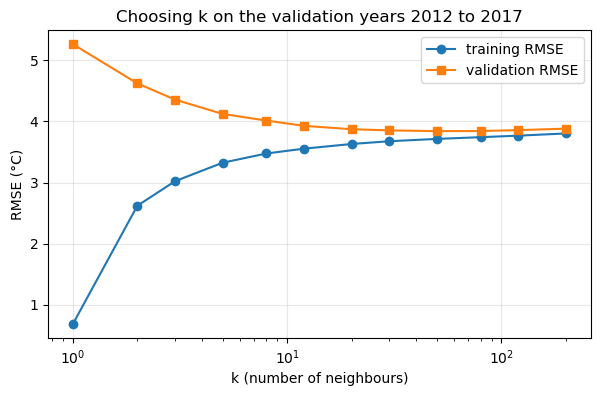

best k on validation: 50


In [10]:
dates = wx["DATE"].values[order]
train = dates < np.datetime64("2012-01-01")
valid = (dates >= np.datetime64("2012-01-01")) & (dates < np.datetime64("2018-01-01"))
test  = dates >= np.datetime64("2018-01-01")
print("train / validation / test rows:", train.sum(), valid.sum(), test.sum())

ks = [1, 2, 3, 5, 8, 12, 20, 30, 50, 80, 120, 200]
train_err, valid_err = [], []
for k in ks:
    m = knn(k).fit(Xo[train], yo[train])
    train_err.append(rmse(yo[train], m.predict(Xo[train])))
    valid_err.append(rmse(yo[valid], m.predict(Xo[valid])))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ks, train_err, "o-", label="training RMSE")
ax.plot(ks, valid_err, "s-", label="validation RMSE")
ax.set_xscale("log")
ax.set_xlabel("k (number of neighbours)")
ax.set_ylabel("RMSE (°C)")
ax.set_title("Choosing k on the validation years 2012 to 2017")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

best_k = ks[int(np.argmin(valid_err))]
print("best k on validation:", best_k)

The two curves tell the whole overfitting story. At $k=1$ the training error is zero, because
every day is its own nearest neighbour, and the validation error is at its worst. As $k$ grows
the model averages over more days, training error rises, validation error falls, and then
turns back up when it starts averaging over days that are no longer similar. The minimum of the
validation curve is the $k$ to use.

Now, and only now, the test set.

In [11]:
final = knn(best_k).fit(Xo[train | valid], yo[train | valid])
print(f"k={best_k}, test years 2018 onward: RMSE = {rmse(yo[test], final.predict(Xo[test])):.2f} °C")
print(f"persistence on the same years:      RMSE = {rmse(yo[test], Xo[test][:, 0]):.2f} °C")

k=50, test years 2018 onward: RMSE = 3.82 °C
persistence on the same years:      RMSE = 4.39 °C


Refitting on training plus validation before the final test is normal practice: the choice of
$k$ has been made, so there is no longer any reason to hold those years back.

## 6. Leakage

Leakage is when information from the test set, or from the future, reaches the model during
training. It produces scores that are too good and models that fail on deployment. Two common
forms.

**Leakage through preprocessing.** Fitting a scaler on all the data before splitting lets the
test set's mean and spread into the training step. For a scaler on this much data the effect is
tiny, but the habit is what matters, because the same mistake with an imputer, a feature
selector, or a target encoder is large. The pipeline above did it correctly by construction.
The cell below does it wrong on purpose.

In [12]:
# Wrong: scaler sees every row, including the test years.
scaler_all = StandardScaler().fit(Xo)
wrong = KNeighborsRegressor(n_neighbors=best_k).fit(scaler_all.transform(Xo[train | valid]), yo[train | valid])
print(f"scaler fitted on all rows:      RMSE = {rmse(yo[test], wrong.predict(scaler_all.transform(Xo[test]))):.3f} °C")

# Right: the pipeline fits the scaler on training rows only.
print(f"scaler inside the pipeline:     RMSE = {rmse(yo[test], final.predict(Xo[test])):.3f} °C")

scaler fitted on all rows:      RMSE = 3.815 °C


scaler inside the pipeline:     RMSE = 3.816 °C


**Leakage through a feature.** Far more dangerous, and easy to do by accident when building
features with `shift`. Suppose we add tomorrow's minimum temperature to the features, which
is a number that does not exist when the forecast is made.

In [13]:
wx["TMIN_tomorrow"] = wx.groupby("station")["TMIN"].shift(-1)
lk = wx.dropna(subset=["TMIN_tomorrow"]).sort_values("DATE")
Xl = lk[features + ["TMIN_tomorrow"]].values
yl = lk["TMAX_tomorrow"].values
tr_l = (lk["DATE"] < "2018-01-01").values
te_l = ~tr_l

m = knn(best_k).fit(Xl[tr_l], yl[tr_l])
print(f"with TMIN_tomorrow as a feature: RMSE = {rmse(yl[te_l], m.predict(Xl[te_l])):.2f} °C")
print("(compare the legitimate model above)")

with TMIN_tomorrow as a feature: RMSE = 3.17 °C
(compare the legitimate model above)


The score improves by more than half a degree, which is more than all the legitimate tuning above
achieved, and nothing in the code looks wrong. No error, no warning, just a model that would
be useless the moment it was asked for a real forecast. The only defence is to ask, for every
feature, "would I have this number at the time the prediction is needed?"

## 7. Does the model degrade over time?

A last check that is specific to environmental data. The climate in the test years is not the
climate in the training years. Score the final model one test year at a time.

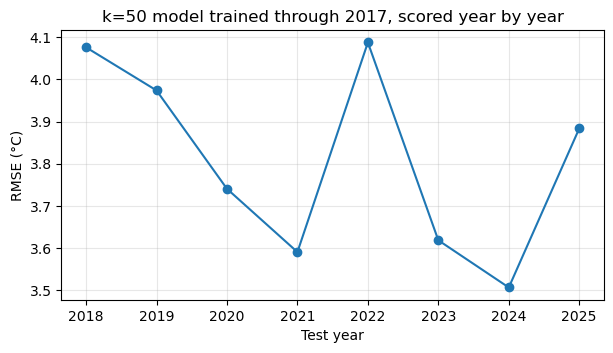

year
2018    4.08
2019    3.97
2020    3.74
2021    3.59
2022    4.09
2023    3.62
2024    3.51
2025    3.88
Name: err, dtype: float64


In [14]:
years = pd.DatetimeIndex(dates[test]).year
pred_test = final.predict(Xo[test])
by_year = pd.DataFrame({"year": years, "err": (yo[test] - pred_test) ** 2}).groupby("year")["err"].mean() ** 0.5

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(by_year.index, by_year.values, "o-")
ax.set_xlabel("Test year")
ax.set_ylabel("RMSE (°C)")
ax.set_title(f"k={best_k} model trained through 2017, scored year by year")
ax.grid(alpha=0.3)
plt.show()
print(by_year.round(2))

For a one-day forecast there is no trend, because persistence carries most of the skill and
persistence does not care what decade it is. For anything that depends on the *level* of the
climate rather than its day-to-day change, this plot is where the trouble shows up first, and
the emulation and forecasting weeks return to it.

## Where this goes next

The recipe: pick the split that matches the question, hold a test set back until the very
end, tune on validation data, and audit every feature for information from the future or from
the sample's identity. That is most of what separates a model that works in the paper from
one that works in the world. Assignment 5 asks you to run the recipe on a sensor calibration
problem, where the gap between a random split and a chronological one is large, and to find
the leakage yourself.